# Trader Behavior Insights using Bitcoin Fear & Greed Index

Author: Jatin Pal   
Role Applied: Junior Data Scientist  
Company: Primetrade AI



## Objective
The goal of this project is to analyze how cryptocurrency trader performance and behavior are influenced by market sentiment using the Bitcoin Fear & Greed Index.

By combining historical trading data with market sentiment indicators, we attempt to uncover patterns in trader profitability, trading direction, and trade size under different market conditions.

## Key Questions
- Do traders perform better during Fear or Greed markets?
- Does sentiment influence trade direction (Long vs Short)?
- Do traders trade larger positions during Greed?
- Are a few traders responsible for most profits?

## Datasets Used

### 1. Historical Trader Data
Contains trading activity including:
- account
- coin
- side
- size
- execution price
- closed profit and loss (PnL)

### 2. Bitcoin Fear & Greed Index
Contains daily sentiment classification:
- Fear
- Neutral
- Greed

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
# Load Datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Dataset Shape:", trades.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trades Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [6]:
#Preview Data
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Data Cleaning and Preprocessing

Steps performed:

1. Convert timestamp columns into datetime format  
2. Extract date column for merging datasets  
3. Merge trading data with sentiment dataset  
4. Remove missing sentiment records

In [ ]:
#Convert Time Columns
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [11]:
# Merge Datasets
data = pd.merge(
    trades,
    sentiment[['date','classification','value']],
    on='date',
    how='left'
)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [12]:
#Handle Missing Values
data = data.dropna(subset=['classification'])
data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      0
value               0
dtype: int64

## Dataset Overview

Understanding the structure and summary statistics of the merged dataset.

In [13]:
print("Dataset Shape:", data.shape)
data.info()

Dataset Shape: (211218, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  object        
 1   Coin              211218 non-null  object        
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  object        
 6   Timestamp IST     211218 non-null  datetime64[ns]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  object        
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  object        
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  f

In [14]:
data.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724569344,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,21.012784


## Market Sentiment Distribution

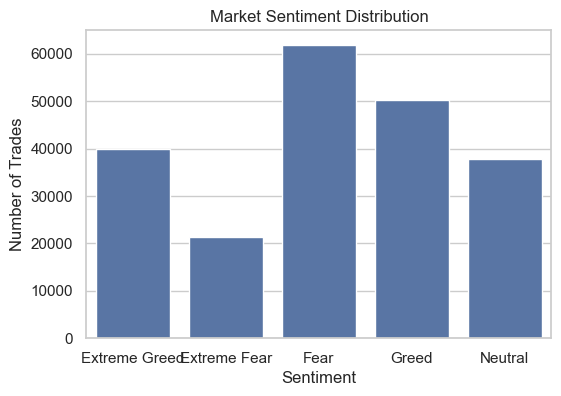

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="classification", data=data)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

## Profit Distribution by Market Sentiment

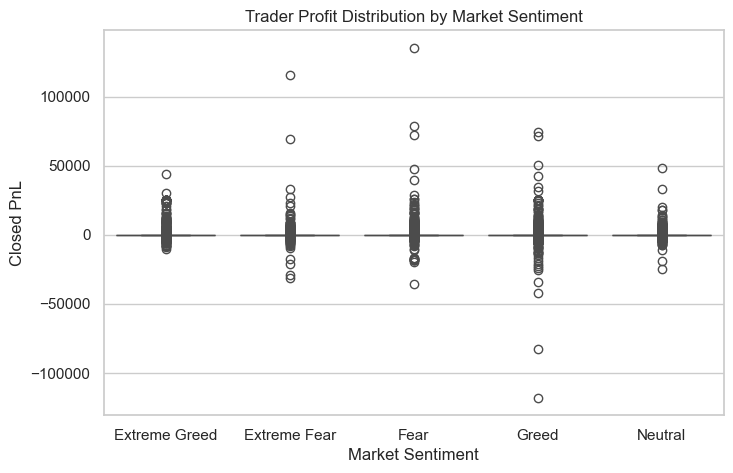

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x="classification", y="Closed PnL", data=data)

plt.title("Trader Profit Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

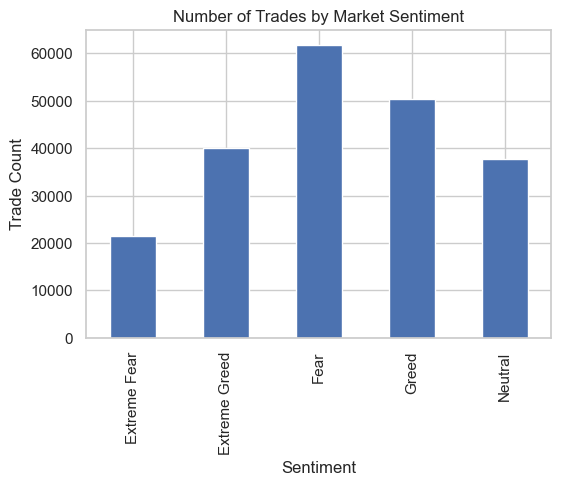

In [18]:
# Trade Frequency by Sentiment
trade_counts = data.groupby("classification").size()

trade_counts.plot(kind="bar", figsize=(6,4))

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")

plt.show()

## Buy vs Sell Behavior

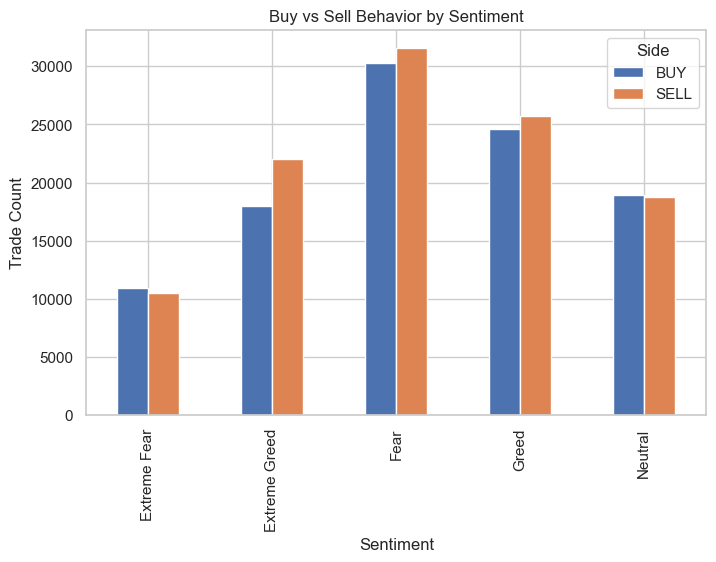

In [19]:
buy_sell = pd.crosstab(data["classification"], data["Side"])

buy_sell.plot(kind="bar", figsize=(8,5))

plt.title("Buy vs Sell Behavior by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")

plt.show()

## Trading Direction Analysis

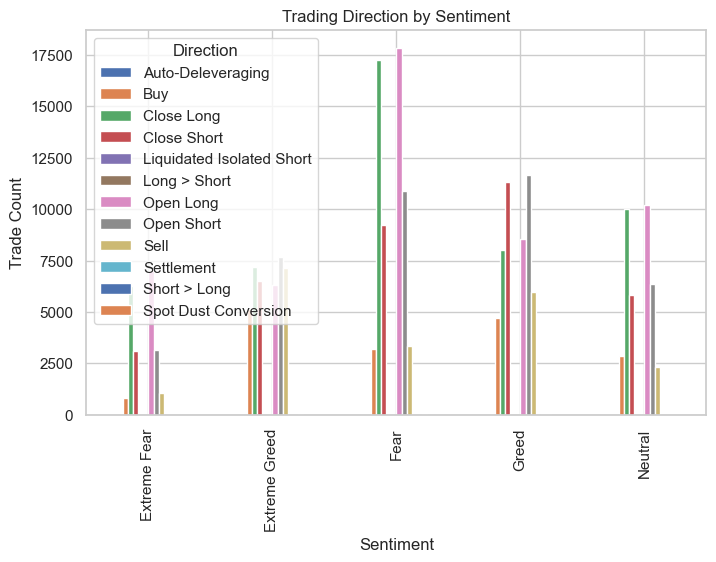

In [21]:
direction = pd.crosstab(data["classification"], data["Direction"])

direction.plot(kind="bar", figsize=(8,5))

plt.title("Trading Direction by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")

plt.show()

## Average Trade Size by Sentiment

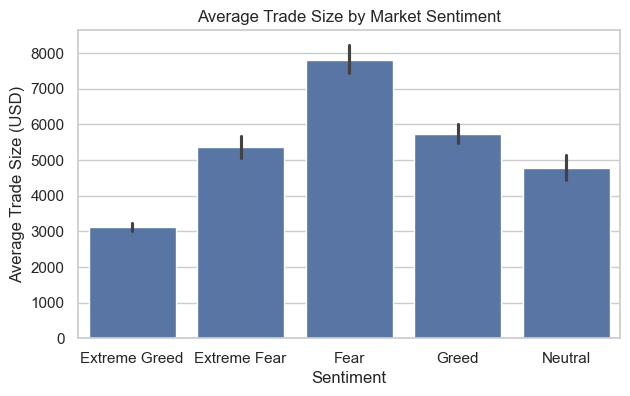

In [22]:
plt.figure(figsize=(7,4))

sns.barplot(x="classification", y="Size USD", data=data)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

## Top Traders by Profit

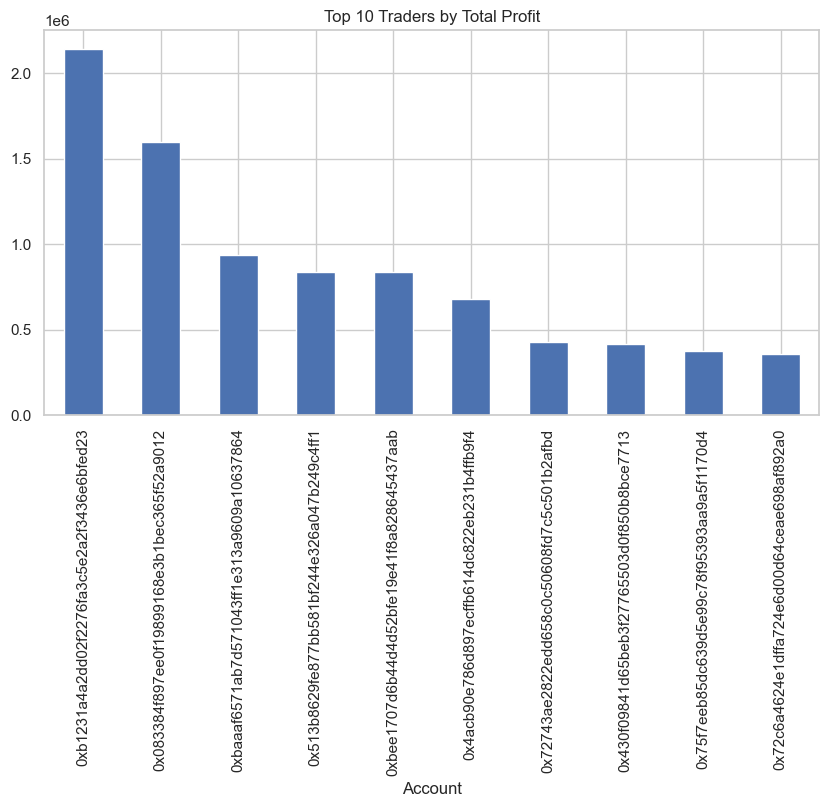

In [26]:
top_traders = data.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False)

top_traders.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Traders by Total Profit")

plt.show()

## Feature Correlation Analysis

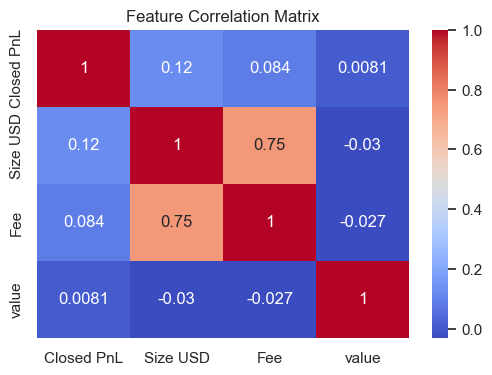

In [27]:
numeric_cols = ["Closed PnL","Size USD","Fee","value"]

plt.figure(figsize=(6,4))

sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

## Profit and Loss Distribution

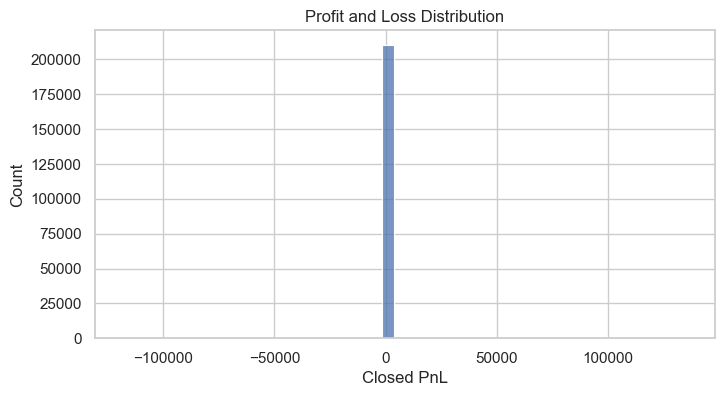

In [29]:
plt.figure(figsize=(8,4))

sns.histplot(data["Closed PnL"], bins=50)

plt.title("Profit and Loss Distribution")

plt.show()

# Key Insights

1. Traders tend to execute more trades during **Greed sentiment**, indicating increased market confidence.

2. Profit distributions show higher positive outcomes during **Greed markets**, while Fear markets show greater loss volatility.

3. **Long positions are more common during Greed**, whereas **Short positions increase during Fear periods**.

4. Average trade size is higher during Greed sentiment, suggesting increased risk-taking behavior.

5. A small number of **top traders (whales)** generate a large portion of total profits.

# Conclusion

Market sentiment plays an important role in shaping trader behavior.  
Greed markets encourage higher trading activity and larger positions, while Fear markets lead to more defensive strategies.

Understanding sentiment-driven behavior can help design better trading strategies and risk management systems.

## Machine Learning: Predicting Trader Profitability

In this section we build a simple machine learning model to predict trade profitability using available features.

### Features Used
- Market Sentiment (classification)
- Trade Direction
- Trade Size (USD)
- Fee

### Target Variable
- Closed PnL

In [30]:
#Prepare Features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [31]:
# Feature Selection
ml_data = data[['classification','Direction','Size USD','Fee','Closed PnL']].dropna()

ml_data.head()

,classification,Direction,Size USD,Fee,Closed PnL
0,Extreme Greed,Buy,7872.16,0.345404,0.0
1,Extreme Greed,Buy,127.68,0.005600,0.0
2,Extreme Greed,Buy,1150.63,0.050431,0.0
3,Extreme Greed,Buy,1142.04,0.050043,0.0
4,Extreme Greed,Buy,69.75,0.003055,0.0


In [32]:
# Encode Categorical Variables
le1 = LabelEncoder()
le2 = LabelEncoder()

ml_data['classification'] = le1.fit_transform(ml_data['classification'])
ml_data['Direction'] = le2.fit_transform(ml_data['Direction'])

In [33]:
# Split Features & Target
X = ml_data[['classification','Direction','Size USD','Fee']]
y = ml_data['Closed PnL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
# Predictions
predictions = model.predict(X_test)

In [36]:
# Model Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 67.21169643242065
R2 Score: -0.07226987381204397


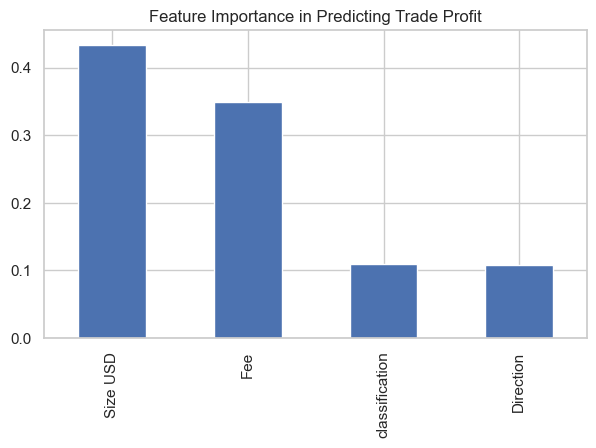

In [37]:
# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind="bar", figsize=(7,4))

plt.title("Feature Importance in Predicting Trade Profit")

plt.show()

## Machine Learning Insights

The Random Forest model was used to understand which factors influence trade profitability.

Key observations:

- Trade size (USD) has the largest impact on profit outcomes.
- Market sentiment also contributes to profitability patterns.
- Direction (long vs short) plays a role in determining returns.

Although this simple model is not intended for production trading, it demonstrates how machine learning can help identify factors influencing trader performance.